In [ ]:
## conda activate gpy_torch_env
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import tqdm
import torch 
from torch.autograd.functional import jacobian
from torch.distributions.multivariate_normal import MultivariateNormal
import gpytorch
import pyro
from pyro.infer import MCMC, NUTS
import pyro.distributions as dist
from scipy.linalg import eigh
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp
from scipy.stats import norm, multivariate_normal, invgamma, uniform
from scipy import interpolate
import pickle



In [70]:
def posterior_metrics(posterior_samples, true_values, credibility_level=0.95):
    """
    Compute RMSE, bias, empirical coverage, and credible interval width
    from posterior samples.

    Parameters
    ----------
    posterior_samples : array-like
        Posterior samples with shape (n_samples, n_parameters)
        or (n_samples,) for a scalar parameter.

    true_values : array-like
        True parameter values with shape (n_parameters,)
        or scalar for a single parameter.

    credibility_level : float, optional
        Credible interval level. Default is 0.95.

    Returns
    -------
    metrics : dict
        Dictionary containing:
        - posterior_mean
        - rmse
        - bias
        - coverage
        - interval_width
        - lower_bound
        - upper_bound
    """

    samples = np.asarray(posterior_samples)
    true_values = np.asarray(true_values)

    # Handle scalar parameter case
    if samples.ndim == 1:
        samples = samples[:, None]
        true_values = np.asarray([true_values])

    alpha = 1.0 - credibility_level
    lower_q = 100 * alpha / 2
    upper_q = 100 * (1 - alpha / 2)

    posterior_mean = np.mean(samples, axis=0)

    lower_bound = np.percentile(samples, lower_q, axis=0)
    upper_bound = np.percentile(samples, upper_q, axis=0)

    bias = posterior_mean - true_values
    # bias = (posterior_mean - true_values)/true_values

    rmse = np.sqrt(bias ** 2)

    coverage = (true_values >= lower_bound) & (true_values <= upper_bound)
    interval_width = upper_bound - lower_bound

    metrics = {
        "posterior_mean": posterior_mean,
        "bias": bias,
        "rmse": rmse,
        "coverage": coverage.astype(float),
        "interval_width": interval_width,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
    }

    return metrics

In [71]:
parameter_names_4spring = ['k_1','c_1','k_2','c_2','k_3','c_3','k_4','c_4']
parameter_names_2spring = ['k_1','c_1','k_2','c_2']
parameter_names_SIRV = ['a','v','\mu','w_r','w_v']
parameter_names_FItz = ['a','b','I','\\tau']

def posterior_plot(chain_IND,chain_MOP,l2_par,true_par,par_names):
    # Analyze the results
    plt.figure(figsize=(14, 12))
    plt.rc('font',size=14)
    if (num_par<5): # 2x2 subplots
        for i in range(num_par):
            plt.subplot(2, 2, i+1)
            plt.hist(chain_IND[i,:], bins=30, density=True,alpha=0.3,color='r',label='KOH')
            plt.hist(chain_MOP[i,:], bins=30, density=True,alpha=0.3,color='b',label='MOS')
            plt.xlabel(rf'${par_names[i]}$')
            plt.axvline(x=l2_par[i],color='k',linestyle='--',label='L2 Minimizer')
            plt.axvline(x=true_par[i],color='r',linestyle='-',label='Data Generating')
        plt.legend(bbox_to_anchor=(0.5, -0.25), loc='upper center', ncol=3)   
        plt.tight_layout()  
        plt.show()
    elif (num_par<7): #3x2 subplots
        for i in range(num_par):
            plt.subplot(3, 2, i+1)
            plt.hist(chain_IND[i,:], bins=30, density=True,alpha=0.3,color='r',label='KOH')
            plt.hist(chain_MOP[i,:], bins=30, density=True,alpha=0.3,color='b',label='MOS')
            plt.xlabel(rf'${par_names[i]}$')
            plt.axvline(x=l2_par[i],color='k',linestyle='--',label='L2 Minimizer')
            plt.axvline(x=true_par[i],color='r',linestyle='-',label='Data Generating')
        plt.legend(bbox_to_anchor=(0.5, -0.25), loc='upper center', ncol=3)     
        plt.tight_layout()
        plt.show()
    elif (num_par<9): #3x3 subplots
        for i in range(num_par):
            plt.subplot(4, 2, i+1)
            plt.hist(chain_IND[i,:], bins=30, density=True,alpha=0.3,color='r',label='KOH')
            plt.hist(chain_MOP[i,:], bins=30, density=True,alpha=0.3,color='b',label='MOS')
            plt.xlabel(rf'${par_names[i]}$')
            plt.axvline(x=l2_par[i],color='k',linestyle='--',label='L2 Minimizer')
            plt.axvline(x=true_par[i],color='r',linestyle='-',label='Data Generating')
        plt.legend(bbox_to_anchor=(0.5, -0.25), loc='upper center', ncol=3)  
        plt.tight_layout()  
        plt.show()
    elif (num_par<12): #3x3 subplots
        for i in range(num_par):
            plt.subplot(4, 3, i+1)
            plt.hist(chain_IND[i,:], bins=30, density=True,alpha=0.3,color='r',label='KOH')
            plt.hist(chain_MOP[i,:], bins=30, density=True,alpha=0.3,color='b',label='MOS')
            plt.xlabel(rf'${par_names[i]}$')
            plt.axvline(x=l2_par[i],color='k',linestyle='--',label='L2 Minimizer')
            plt.axvline(x=true_par[i],color='r',linestyle='-',label='Data Generating')
        plt.legend(bbox_to_anchor=(0.5, -0.25), loc='upper center', ncol=3)    
        plt.tight_layout() 
        plt.show()
    plt.rc('font',size=10)

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\Users\colebanm\AppData\Local\Temp\ipykernel_1108104\1980085198.py:3: SyntaxWarning: invalid escape sequence '\m'
  parameter_names_SIRV = ['a','v','\mu','w_r','w_v']


[ 1.          0.1        11.18868775  0.53027336] [ 0.7996841  0.9502601 24.839375   0.4697972  0.3188839 13.740134 ]


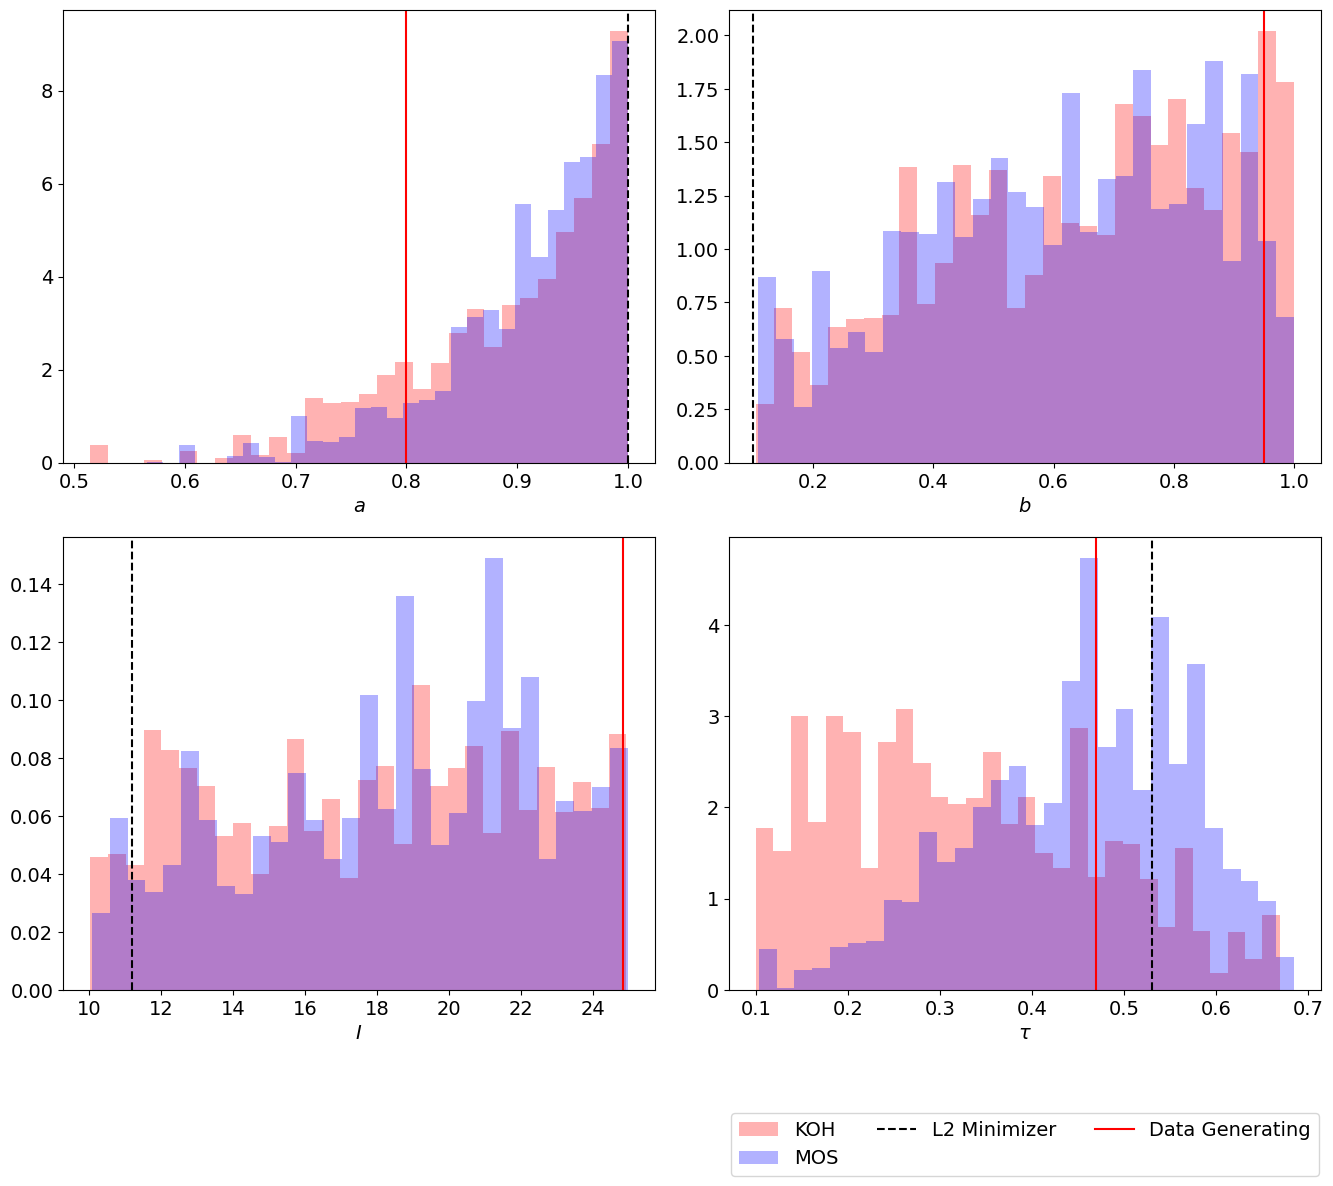

In [65]:
num_par = 4 #leave off discrepancy hyperparameters
burnin = 5000

mean_KOH = np.zeros((num_par,100))
bias_KOH = np.zeros((num_par,100))
RMSE_KOH = np.zeros((num_par,100))
cover_KOH = np.zeros((num_par,100))
int_wid_KOH = np.zeros((num_par,100))
LB_KOH = np.zeros((num_par,100))
UB_KOH = np.zeros((num_par,100))

mean_MOP = np.zeros((num_par,100))
bias_MOP = np.zeros((num_par,100))
RMSE_MOP = np.zeros((num_par,100))
cover_MOP = np.zeros((num_par,100))
int_wid_MOP = np.zeros((num_par,100))
LB_MOP = np.zeros((num_par,100))
UB_MOP = np.zeros((num_par,100))

for i in range(1):
    if i<10:
        fname = 'Fitz_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_100signal_results/signal_00'+f'{i}' + '_results.pkl'
    else:
        fname = 'Fitz_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_100signal_results/signal_0'+f'{i}' + '_results.pkl'

    

    with open(fname, 'rb') as f:
        data = pickle.load(f)

    chain_IND_all = data['chain_IND_all']
    chain_MOP_all = data['chain_MOP_all']
    s2chain_IND_all = data['s2chain_IND_all']
    s2chain_MOP_all = data['s2chain_MOP_all']

    l2_par = data['x_sorted'][0,:]
    data_generating_par = data['theta_all_true']
    print(l2_par,data_generating_par)

    

    chain_IND = chain_IND_all[0,:-2,burnin:]
    chain_MOP = chain_MOP_all[0,:-2,burnin:]

    posterior_plot(chain_IND,chain_MOP,l2_par,data_generating_par,par_names=parameter_names_FItz)


    





In [79]:
num_par = 4 #leave off discrepancy hyperparameters
burnin = 5000

mean_KOH = np.zeros((num_par,100))
bias_KOH = np.zeros((num_par,100))
RMSE_KOH = np.zeros((num_par,100))
cover_KOH = np.zeros((num_par,100))
int_wid_KOH = np.zeros((num_par,100))
LB_KOH = np.zeros((num_par,100))
UB_KOH = np.zeros((num_par,100))

mean_MOP = np.zeros((num_par,100))
bias_MOP = np.zeros((num_par,100))
RMSE_MOP = np.zeros((num_par,100))
cover_MOP = np.zeros((num_par,100))
int_wid_MOP = np.zeros((num_par,100))
LB_MOP = np.zeros((num_par,100))
UB_MOP = np.zeros((num_par,100))

for i in range(100):
    if i<10:
        # fname = 'Fitz_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        fname = 'TwoSpring_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_100signal_results/signal_00'+f'{i}' + '_results.pkl'
    else:
        # fname = 'Fitz_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        fname = 'TwoSpring_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_100signal_results/signal_0'+f'{i}' + '_results.pkl'

    

    with open(fname, 'rb') as f:
        data = pickle.load(f)

    chain_IND_all = data['chain_IND_all']
    chain_MOP_all = data['chain_MOP_all']
    s2chain_IND_all = data['s2chain_IND_all']
    s2chain_MOP_all = data['s2chain_MOP_all']

    l2_par = data['x_sorted'][0,:]
    data_generating_par = data['theta_all_true'][:-2]
    # print(l2_par,data_generating_par)

    

    chain_IND = chain_IND_all[0,:-2,burnin:]
    chain_MOP = chain_MOP_all[0,:-2,burnin:]
    metrics_KOH = posterior_metrics(chain_IND.T, data_generating_par, credibility_level=0.95)
    metrics_MOP = posterior_metrics(chain_MOP.T, data_generating_par, credibility_level=0.95)

    mean_KOH[:,i] = (metrics_KOH['posterior_mean'])
    bias_KOH[:,i] = (metrics_KOH['bias'])
    RMSE_KOH[:,i] = (metrics_KOH['rmse'])
    cover_KOH[:,i] = (metrics_KOH['coverage'])
    int_wid_KOH[:,i] = (metrics_KOH['interval_width'])
    LB_KOH[:,i] = (metrics_KOH['lower_bound'])
    UB_KOH[:,i] = (metrics_KOH['upper_bound'])

    mean_MOP[:,i] = (metrics_MOP['posterior_mean'])
    bias_MOP[:,i] = (metrics_MOP['bias'])
    RMSE_MOP[:,i] = (metrics_MOP['rmse'])
    cover_MOP[:,i] = (metrics_MOP['coverage'])
    int_wid_MOP[:,i] = (metrics_MOP['interval_width'])
    LB_MOP[:,i] = (metrics_MOP['lower_bound'])
    UB_MOP[:,i] = (metrics_MOP['upper_bound'])





In [80]:
metrics_KOH['interval_width']

array([30.372345 ,  4.5955772, 33.65496  ,  4.243533 ], dtype=float32)

In [81]:
metrics = {
    "mean_KOH": mean_KOH,
    "mean_MOP": mean_MOP,

    "bias_KOH": bias_KOH,
    "bias_MOP": bias_MOP,

    "RMSE_KOH": RMSE_KOH,
    "RMSE_MOP": RMSE_MOP,

    "int_wid_KOH": int_wid_KOH,
    "int_wid_MOP": int_wid_MOP,

    "LB_KOH": LB_KOH,
    "LB_MOP": LB_MOP,

    "UB_KOH": UB_KOH,
    "UB_MOP": UB_MOP,
}

from scipy.stats import t
def summarize_metric(x, axis=1, confidence=0.95):
    """
    Summarize a metric array.

    Assumes x has shape (num_par, num_reps), e.g. (num_par, 50).
    By default, summaries are calculated across the 50 replicates
    separately for each parameter.
    """

    n = x.shape[axis]

    sample_mean = np.mean(x, axis=axis)
    sample_median = np.median(x, axis=axis)
    sample_variance = np.var(x, axis=axis, ddof=1)

    sample_std = np.std(x, axis=axis, ddof=1)
    se = sample_std / np.sqrt(n)

    alpha = 1 - confidence
    t_crit = t.ppf(1 - alpha / 2, df=n - 1)

    ci_lower = sample_mean - t_crit * se
    ci_upper = sample_mean + t_crit * se

    return {
        "mean": sample_mean,
        "median": sample_median,
        "variance": sample_variance,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
    }

summary = {
    name: summarize_metric(arr, axis=1)
    for name, arr in metrics.items()
}

In [82]:
summary

{'mean_KOH': {'mean': array([51.11797801,  5.40942531, 47.94807843,  5.13912478]),
  'median': array([52.28743744,  5.96375322, 48.74651718,  5.3598578 ]),
  'variance': array([785.59525245,   5.07503746, 755.93399125,   5.30574907]),
  'ci_lower': array([45.55652105,  4.96242401, 42.49262198,  4.68207605]),
  'ci_upper': array([56.67943497,  5.8564266 , 53.40353487,  5.59617351])},
 'mean_MOP': {'mean': array([50.74134316,  5.33958192, 48.12631656,  5.14777334]),
  'median': array([51.57715797,  5.58587217, 46.99059677,  5.34374332]),
  'variance': array([806.01120216,   5.6748563 , 775.09059571,   5.69479595]),
  'ci_lower': array([45.10808448,  4.86690261, 42.6021675 ,  4.67426434]),
  'ci_upper': array([56.37460184,  5.81226122, 53.65046563,  5.62128234])},
 'bias_KOH': {'mean': array([ 0.20470984,  0.30538368, -0.39980103,  0.24358263]),
  'median': array([0.2452879 , 0.18114305, 0.26325238, 0.26232553]),
  'variance': array([32.19264205,  1.5157777 , 31.83611773,  1.04692333]),
 

In [83]:
for metric_name, stats in summary.items():
    print(f"\n{metric_name}")
    for par_idx in range(num_par):
        print(
            f"Parameter {par_idx}: "
            f"mean={stats['mean'][par_idx]:.4f}, "
            f"median={stats['median'][par_idx]:.4f}, "
            f"variance={stats['variance'][par_idx]:.4f}, "
            f"95% CI=({stats['ci_lower'][par_idx]:.4f}, "
            f"{stats['ci_upper'][par_idx]:.4f})"
        )


mean_KOH
Parameter 0: mean=51.1180, median=52.2874, variance=785.5953, 95% CI=(45.5565, 56.6794)
Parameter 1: mean=5.4094, median=5.9638, variance=5.0750, 95% CI=(4.9624, 5.8564)
Parameter 2: mean=47.9481, median=48.7465, variance=755.9340, 95% CI=(42.4926, 53.4035)
Parameter 3: mean=5.1391, median=5.3599, variance=5.3057, 95% CI=(4.6821, 5.5962)

mean_MOP
Parameter 0: mean=50.7413, median=51.5772, variance=806.0112, 95% CI=(45.1081, 56.3746)
Parameter 1: mean=5.3396, median=5.5859, variance=5.6749, 95% CI=(4.8669, 5.8123)
Parameter 2: mean=48.1263, median=46.9906, variance=775.0906, 95% CI=(42.6022, 53.6505)
Parameter 3: mean=5.1478, median=5.3437, variance=5.6948, 95% CI=(4.6743, 5.6213)

bias_KOH
Parameter 0: mean=0.2047, median=0.2453, variance=32.1926, 95% CI=(-0.9211, 1.3305)
Parameter 1: mean=0.3054, median=0.1811, variance=1.5158, 95% CI=(0.0611, 0.5497)
Parameter 2: mean=-0.3998, median=0.2633, variance=31.8361, 95% CI=(-1.5194, 0.7198)
Parameter 3: mean=0.2436, median=0.2623

In [84]:
results = {
    "mean_KOH": mean_KOH,
    "bias_KOH": bias_KOH,
    "RMSE_KOH": RMSE_KOH,
    "cover_KOH": cover_KOH,
    "int_wid_KOH": int_wid_KOH,
    "LB_KOH": LB_KOH,
    "UB_KOH": UB_KOH,

    "mean_MOP": mean_MOP,
    "bias_MOP": bias_MOP,
    "RMSE_MOP": RMSE_MOP,
    "cover_MOP": cover_MOP,
    "int_wid_MOP": int_wid_MOP,
    "LB_MOP": LB_MOP,
    "UB_MOP": UB_MOP,
}

# Save to pickle file
with open("TwoSpring_posterior_metrics_TruePar_Final.pkl", "wb") as f:
    pickle.dump(results, f)
    pickle.dump(summary,f)

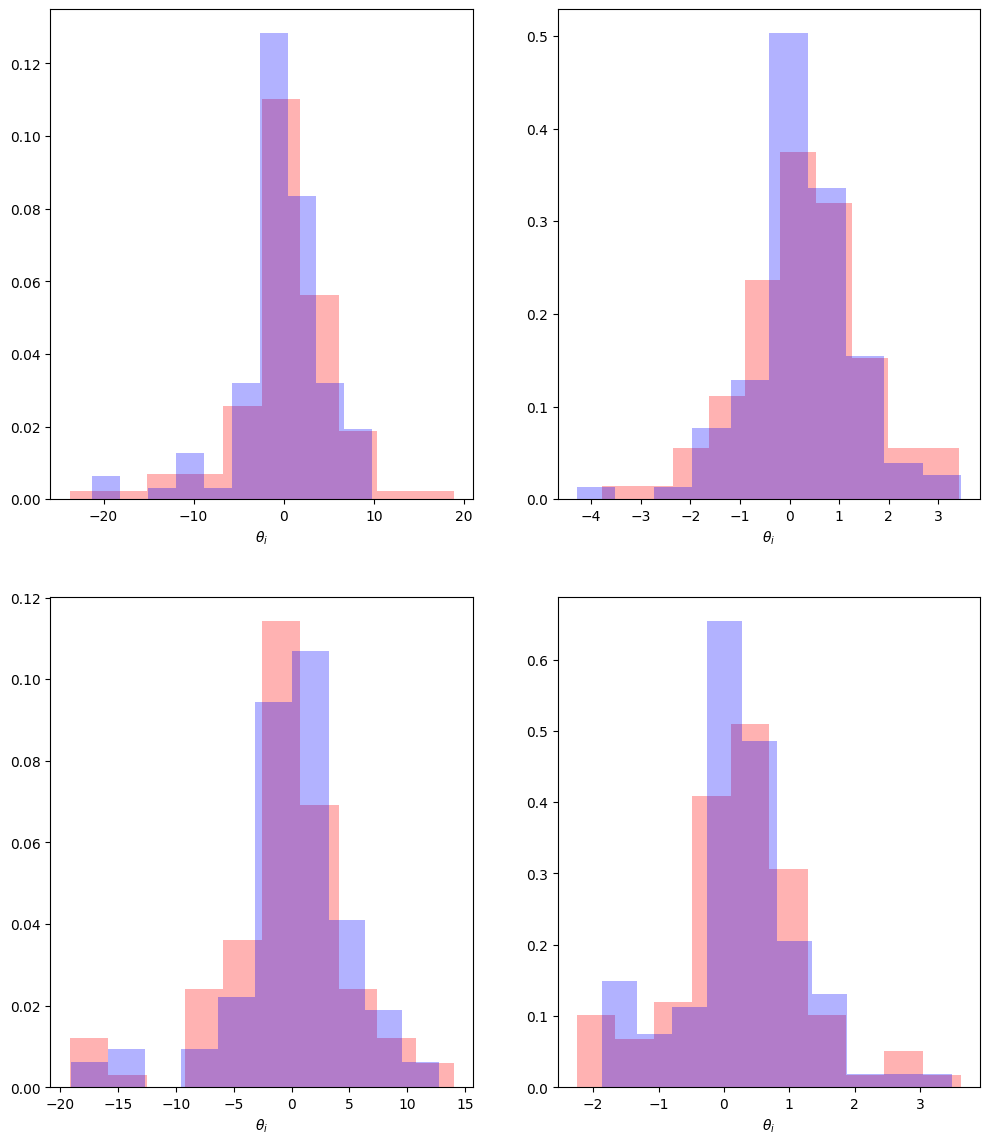

In [85]:
plt.figure(figsize=(12, 14))
if (num_par<5): # 2x2 subplots
    for i in range(num_par):
        plt.subplot(2, 2, i+1)
        plt.hist(bias_KOH[i], bins=10, density=True,alpha=0.3,color='r',label='IND')
        plt.hist(bias_MOP[i], bins=10, density=True,alpha=0.3,color='b',label='Orth')
        plt.xlabel(r'$\theta_{i}$ ')
    plt.show()
elif (num_par<7): #3x2 subplots
    for i in range(num_par):
        plt.subplot(3, 2, i+1)
        plt.hist(bias_KOH[i], bins=10, density=True,alpha=0.3,color='r',label='IND')
        plt.hist(bias_MOP[i], bins=10, density=True,alpha=0.3,color='b',label='Orth')
        plt.xlabel(r'$\theta_{i}$ ')
    plt.show()
elif (num_par<9): #3x3 subplots
    for i in range(num_par):
        plt.subplot(3, 3, i+1)
        plt.hist(bias_KOH[i], bins=10, density=True,alpha=0.3,color='r',label='IND')
        plt.hist(bias_MOP[i], bins=10, density=True,alpha=0.3,color='b',label='Orth')
        plt.xlabel(r'$\theta_{i}$ ')
    plt.show()
elif (num_par<12): #3x3 subplots
    for i in range(num_par):
        plt.subplot(4, 3, i+1)
        plt.hist(bias_KOH[i], bins=10, density=True,alpha=0.3,color='r',label='IND')
        plt.hist(bias_MOP[i], bins=10, density=True,alpha=0.3,color='b',label='Orth')
        plt.xlabel(r'$\theta_{i}$ ')
    plt.show()

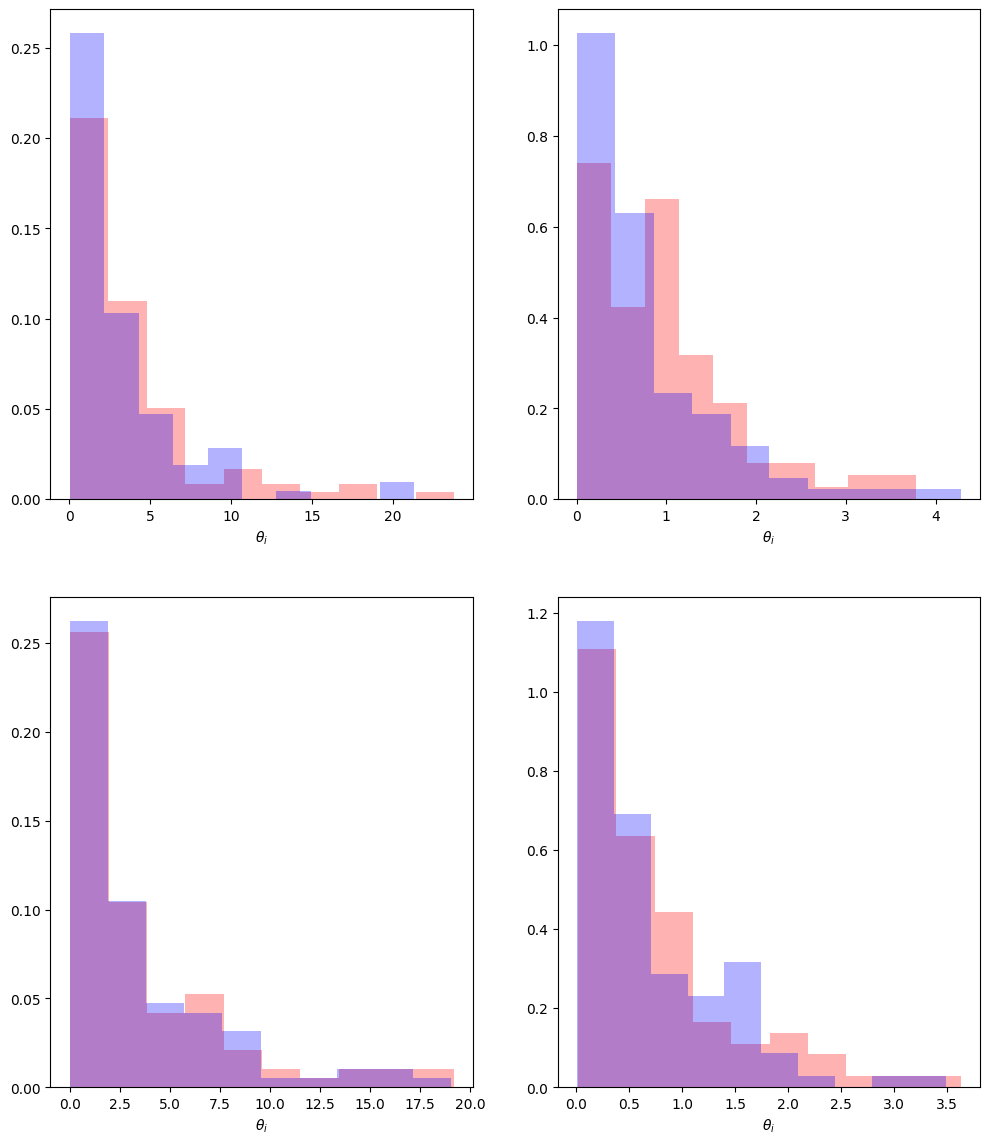

In [86]:
plt.figure(figsize=(12, 14))
if (num_par<5): # 2x2 subplots
    for i in range(num_par):
        plt.subplot(2, 2, i+1)
        plt.hist(RMSE_KOH[i], bins=10, density=True,alpha=0.3,color='r',label='IND')
        plt.hist(RMSE_MOP[i], bins=10, density=True,alpha=0.3,color='b',label='Orth')
        plt.xlabel(r'$\theta_{i}$ ')
    plt.show()
elif (num_par<7): #3x2 subplots
    for i in range(num_par):
        plt.subplot(3, 2, i+1)
        plt.hist(RMSE_KOH[i], bins=10, density=True,alpha=0.3,color='r',label='IND')
        plt.hist(RMSE_MOP[i], bins=10, density=True,alpha=0.3,color='b',label='Orth')
        plt.xlabel(r'$\theta_{i}$ ')
    plt.show()
elif (num_par<9): #3x3 subplots
    for i in range(num_par):
        plt.subplot(3, 3, i+1)
        plt.hist(RMSE_KOH[i], bins=10, density=True,alpha=0.3,color='r',label='IND')
        plt.hist(RMSE_MOP[i], bins=10, density=True,alpha=0.3,color='b',label='Orth')
        plt.xlabel(r'$\theta_{i}$ ')
    plt.show()
elif (num_par<12): #3x3 subplots
    for i in range(num_par):
        plt.subplot(4, 3, i+1)
        plt.hist(RMSE_KOH[i], bins=10, density=True,alpha=0.3,color='r',label='IND')
        plt.hist(RMSE_MOP[i], bins=10, density=True,alpha=0.3,color='b',label='Orth')
        plt.xlabel(r'$\theta_{i}$ ')
    plt.show()